# Churn Prediction

The dataset used in this project contains information about customer transactions and demographics. The original dataset is from Kaggle and can be found [here](https://www.kaggle.com/datasets/computingvictor/transactions-fraud-datasets). It has been modified for the purpose of this project.

The objective is to build a predictive model that can accurately classify whether a customer will churn based on these features.

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.simplefilter('ignore')

%config InlineBackend.figure_format = "retina"

## Data

In [2]:
# Read data
path_data = "https://github.com/pabloestradac/causalml-basics/raw/main/data/"
df = pd.read_csv(path_data + 'churn.csv')
df.describe().round(2)

,num_transactions,total_amount,avg_amount,std_amount,churn,current_age,yearly_income,total_debt,credit_score,num_credit_cards
count,1219.00,1219.00,1219.00,1219.00,1219.00,1219.00,1219.00,1219.00,1219.00,1219.00
mean,10915.43,469102.15,43.91,78.71,0.03,53.05,45117.95,58196.86,713.22,3.70
std,5607.36,292602.85,17.48,27.27,0.18,15.66,23292.43,51255.43,65.55,1.57
min,760.00,26605.34,5.34,9.71,0.00,23.00,1.00,0.00,488.00,1.00
25%,7223.50,269693.84,32.22,61.25,0.00,41.00,32075.00,18527.50,684.00,3.00
50%,9832.00,398837.16,40.72,74.25,0.00,51.00,40012.00,51984.00,715.00,4.00
75%,13349.00,597774.02,52.55,91.87,0.00,63.00,52176.50,84080.50,755.00,5.00
max,48479.00,2445773.25,147.24,279.91,1.00,101.00,280199.00,461854.00,850.00,9.00


In [3]:
df.head(10)

,num_transactions,total_amount,avg_amount,std_amount,churn,current_age,gender,yearly_income,total_debt,credit_score,num_credit_cards
0,12795,625799.67,48.909705,84.635746,0,33,Male,59613.0,36199.0,763,4
1,10073,336187.37,33.375099,52.139254,0,43,Female,45360.0,14587.0,704,3
2,10612,291534.27,27.472132,43.120595,0,48,Male,27447.0,80850.0,673,5
3,6001,280685.46,46.773114,40.747430,0,49,Male,27943.0,18693.0,681,4
4,15043,595722.36,39.601300,75.924251,0,54,Female,76431.0,115362.0,716,5
5,4777,292902.60,61.315177,119.144323,0,65,Male,20614.0,14042.0,711,2
6,9994,585903.46,58.625521,99.883268,0,39,Female,67643.0,0.0,714,6
7,7109,242998.23,34.181774,72.091164,0,52,Female,32378.0,65919.0,588,4
8,5843,233831.77,40.019129,87.973165,0,79,Female,32232.0,21134.0,652,5
9,6829,378672.72,55.450684,90.927975,0,75,Male,22158.0,19101.0,681,5


## Using Statsmodels for Logistic Regression

In logistic regression, the dependent variable is binary, and the goal is to model the probability that the dependent variable belongs to a particular category. In this case, the dependent variable will indicate whether a customer has churned. This is

$$
P(\text{Churn} = 1 | X) = \frac{e^{\beta_0 + \beta_1 X_1 + \ldots + \beta_p X_p}}{1 + e^{\beta_0 + \beta_1 X_1 + \ldots + \beta_p X_p}} ,
$$

where $X = (X_1, \ldots, X_p)$ are the predictors, and $\beta = (\beta_0, \ldots, \beta_p)$ are the coefficients.

The `GLM()` function from the `statsmodels` library will be used to perform logistic regression using the class of generalized linear models. Alternatively, the function `Logit()` fits a logistic regression model directly. The syntax of `GLM()` is similar to that of sm.OLS(), except that we must pass in the argument `family=sm.families.Binomial()`.

In [4]:
import patsy

model = ('num_transactions + avg_amount + std_amount + current_age + '
         'gender + np.log1p(yearly_income) + np.log1p(total_debt) + credit_score + num_credit_cards')
Xbase = patsy.dmatrix(model, df, return_type='dataframe')
y = df['churn']

In [5]:
import statsmodels.api as sm

# Linear probability model
model = sm.OLS(y, Xbase)
results = model.fit()
results.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.1432,0.101,1.412,0.158,-0.056,0.342
gender[T.Male],0.0100,0.010,0.976,0.329,-0.010,0.030
num_transactions,-4.087e-06,9.89e-07,-4.131,0.000,-6.03e-06,-2.15e-06
avg_amount,0.0005,0.000,1.226,0.221,-0.000,0.001
std_amount,2.873e-05,0.000,0.098,0.922,-0.001,0.001
current_age,-0.0008,0.000,-2.207,0.028,-0.002,-9.25e-05
np.log1p(yearly_income),0.0081,0.008,0.967,0.334,-0.008,0.025
np.log1p(total_debt),-0.0017,0.002,-0.836,0.403,-0.006,0.002
credit_score,-0.0001,8.24e-05,-1.493,0.136,-0.000,3.86e-05
num_credit_cards,-0.0085,0.004,-2.263,0.024,-0.016,-0.001


Interpretation: one more credit card decreases the probability of churn by 0.85 percentage points.

In [6]:
# Logistic regression
model = sm.Logit(y, Xbase)
results = model.fit()
results.summary().tables[1]

Optimization terminated successfully.
         Current function value: 0.119432
         Iterations 9


,coef,std err,z,P>|z|,[0.025,0.975]
Intercept,-7.6918,5.855,-1.314,0.189,-19.168,3.784
gender[T.Male],0.2546,0.335,0.759,0.448,-0.403,0.912
num_transactions,-0.0003,6.08e-05,-4.948,0.000,-0.000,-0.000
avg_amount,0.0207,0.014,1.459,0.145,-0.007,0.049
std_amount,-0.0138,0.010,-1.429,0.153,-0.033,0.005
current_age,-0.0316,0.014,-2.330,0.020,-0.058,-0.005
np.log1p(yearly_income),1.1346,0.571,1.987,0.047,0.015,2.254
np.log1p(total_debt),-0.0640,0.065,-0.989,0.322,-0.191,0.063
credit_score,-0.0032,0.003,-1.270,0.204,-0.008,0.002
num_credit_cards,-0.2526,0.140,-1.805,0.071,-0.527,0.022


Interpretation: one more credit card decreases the log-odds of churn by 0.25

### Logistic regression from scratch

Using the same $X$ and $y$, maximize the Bernoulli log-likelihood:

$$
\ell(\beta)=\sum_{i=1}^n\left[y_i x_i^\top\beta-\log(1+e^{x_i^\top\beta})\right].
$$

The code below implements Newton's method directly, using the score $X^\top(y-q)$ and information matrix $X^\top W X$, where $q_i=(1+e^{-x_i^\top\beta})^{-1}$ and $W_{ii}=q_i(1-q_i)$. No logistic-regression fitter or optimizer is used for the manual estimates; the existing estimates above are included only for comparison.

In [7]:
# Work with the same design matrix, including its intercept.
X_manual = Xbase.to_numpy(dtype=float)
y_manual = np.asarray(y, dtype=float)
assert Xbase.columns[0] == 'Intercept'

# Standardize internally for stable linear algebra; keep the intercept unchanged.
manual_mean = X_manual.mean(axis=0)
manual_scale = X_manual.std(axis=0)
manual_mean[0], manual_scale[0] = 0.0, 1.0
Z_manual = (X_manual - manual_mean) / manual_scale

def manual_log_likelihood(beta):
    eta = Z_manual @ beta
    # Equivalent to sum(y * eta - log(1 + exp(eta))), without overflow.
    return -np.logaddexp(0.0, (1 - 2 * y_manual) * eta).sum()

beta_manual_scaled = np.zeros(Z_manual.shape[1])
for manual_iteration in range(1, 101):
    eta = Z_manual @ beta_manual_scaled
    q = np.exp(-np.logaddexp(0.0, -eta))  # Stable logistic probability.
    score = Z_manual.T @ (y_manual - q)
    information = Z_manual.T @ ((q * (1 - q))[:, None] * Z_manual)
    if np.max(np.abs(score)) < 1e-8:
        break

    # Newton step: solve the linear system instead of inverting the matrix.
    step = np.linalg.solve(information, score)
    step_size = 1.0
    old_ll = manual_log_likelihood(beta_manual_scaled)
    # Backtracking prevents a Newton step from decreasing the likelihood.
    while manual_log_likelihood(beta_manual_scaled + step_size * step) < old_ll:
        step_size *= 0.5
        if step_size < 1e-12:
            raise RuntimeError('Newton step stalled; inspect convergence.')
    beta_manual_scaled += step_size * step
else:
    raise RuntimeError('Manual logistic regression did not converge.')

# Return coefficients and curvature-based standard errors to the original units.
manual_transform = np.diag(1 / manual_scale)
manual_transform[0, :] -= manual_mean / manual_scale
beta_manual = manual_transform @ beta_manual_scaled
manual_covariance = manual_transform @ np.linalg.solve(
    information, np.eye(information.shape[0])
) @ manual_transform.T
manual_se = np.sqrt(np.diag(manual_covariance))

# 'results' remains the earlier statsmodels fit, used next for marginal effects.
manual_table = pd.DataFrame({
    'Manual coefficient': beta_manual,
    'Manual std. error': manual_se,
    'Earlier coefficient': np.asarray(results.params),
}, index=Xbase.columns)
print(f'Converged after {manual_iteration - 1} Newton updates; '
      f'log-likelihood = {manual_log_likelihood(beta_manual_scaled):.6f}')
manual_table.round(6)

Converged after 8 Newton updates; log-likelihood = -145.587824


,Manual coefficient,Manual std. error,Earlier coefficient
Intercept,-7.691816,5.855262,-7.691816
gender[T.Male],0.254574,0.335395,0.254574
num_transactions,-0.000301,0.000061,-0.000301
avg_amount,0.020749,0.014225,0.020749
std_amount,-0.013751,0.009621,-0.013751
current_age,-0.031630,0.013577,-0.031630
np.log1p(yearly_income),1.134645,0.571014,1.134645
np.log1p(total_debt),-0.063993,0.064673,-0.063993
credit_score,-0.003198,0.002517,-0.003198
num_credit_cards,-0.252601,0.139943,-0.252601


In [8]:
marginal_effects = results.get_margeff()
marginal_effects.summary().tables[1]

,dy/dx,std err,z,P>|z|,[0.025,0.975]
gender[T.Male],0.0076,0.010,0.758,0.449,-0.012,0.027
num_transactions,-9.029e-06,2.02e-06,-4.471,0.000,-1.3e-05,-5.07e-06
avg_amount,0.0006,0.000,1.443,0.149,-0.000,0.001
std_amount,-0.0004,0.000,-1.413,0.158,-0.001,0.000
current_age,-0.0009,0.000,-2.272,0.023,-0.002,-0.000
np.log1p(yearly_income),0.0340,0.017,1.959,0.050,-1.25e-05,0.068
np.log1p(total_debt),-0.0019,0.002,-0.984,0.325,-0.006,0.002
credit_score,-9.59e-05,7.6e-05,-1.262,0.207,-0.000,5.3e-05
num_credit_cards,-0.0076,0.004,-1.776,0.076,-0.016,0.001


Interpretation: one more credit card decreases the probability of churn by 0.76 percentage points.

## Using Scikit-learn for Logistic Regression

### Intuition and functional form

Let $Y=1$ mean churn, $Y=0$ mean no churn, and $x=(x_1,\ldots,x_p)^\top$ contain a customer's predictors. Logistic regression directly models the conditional probability of churn:

$$
s(x)=\beta_0+\beta^\top x, \qquad
P(Y=1\mid x)=\frac{1}{1+\exp[-s(x)]}.
$$

Each feature adds to or subtracts from a linear score; the logistic function turns that score into a probability. The coefficients are fitted to observed outcomes, with regularization in the scikit-learn implementation used here.

To classify, choose a probability threshold $t$: predict churn when $\widehat P(Y=1\mid x)\geq t$. At the usual threshold $t=0.5$, this is equivalent to $s(x)\geq0$. The boundary is therefore **linear in the supplied features**, even though the probability function is curved. With two features it is a line; with more it is a hyperplane. Because some predictors in this notebook are logarithms, the boundary need not be linear in the original, untransformed variables.

A customer can have a higher predicted risk than another customer while both probabilities remain below 0.5. This distinction between **risk ranking** and **classification at a threshold** will matter for the ROC curve.


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(Xbase, y, test_size=0.5, random_state=42)

# Fit the model
clf = LogisticRegression()
clf.fit(X_train, y_train)

# Make predictions with train data
y_pred = clf.predict(X_train)

# Confusion matrix
confusion_matrix(y_train, y_pred)

array([[590,   0],
       [ 18,   1]])

### Reading the confusion matrix

For `confusion_matrix(y_train, y_pred)`, **rows are actual classes and columns are predicted classes**, ordered here as 0 (no churn), then 1 (churn).

| Actual outcome | Predicted no churn (0) | Predicted churn (1) |
|---|---:|---:|
| No churn (0) | 590 true negatives | 0 false positives |
| Churn (1) | 18 false negatives | 1 true positive |

The diagonal contains correct predictions; the off-diagonal cells contain mistakes. Here “positive” means churn.

Think of the classifier as a churn alarm. It raised the alarm only once, and that alarm was correct. But it **missed 18 of the 19 customers who actually churned**.

$$
\text{Accuracy}=\frac{TP+TN}{N}=\frac{1+590}{609}\approx97.0\%.
$$

This apparently high accuracy reflects the class imbalance: predicting “no churn” for everyone would already achieve $590/609\approx96.9\%$. Correctly classifying the majority can hide poor detection of the minority.


In [10]:
# Evaluate the model
print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       590
           1       1.00      0.05      0.10        19

    accuracy                           0.97       609
   macro avg       0.99      0.53      0.54       609
weighted avg       0.97      0.97      0.96       609



### Reading `classification_report`

The report summarizes the same predictions, treating each class in turn as the class of interest.

| Column | Question it answers |
|---|---|
| Precision | Of the customers predicted to belong to this class, how many actually belong to it? |
| Recall | Of the customers actually in this class, how many did the model find? |
| F1-score | How well does the model balance precision and recall? |
| Support | How many observations actually belong to this class? |

For churn (class 1), the formulas are:

$$
\text{Precision}=\frac{TP}{TP+FP},\qquad
\text{Recall}=\frac{TP}{TP+FN},\qquad
F_1=\frac{2\,\text{Precision}\,\text{Recall}}{\text{Precision}+\text{Recall}}.
$$

**Class 1 (churn):** Precision is $1/(1+0)=1.00$: the only churn prediction was correct. Recall is $1/(1+18)\approx0.05$: only one of 19 churners was detected. Their harmonic mean is $F_1=0.10$. Support is 19. Perfect precision therefore does **not** mean that all churners were found; here it rests on just one prediction.

**Class 0 (no churn):** Of the 608 customers predicted to stay, 590 stayed, giving precision $590/608\approx0.97$. All 590 actual non-churners were identified, giving recall 1.00. F1 is approximately 0.98 and support is 590.

| Summary row | Calculation | Interpretation of this output |
|---|---|---|
| Accuracy | Correct predictions divided by all observations | About 97% correct overall |
| Macro avg | Unweighted mean of each metric across classes | Each class has equal influence; macro F1 of 0.54 reveals uneven performance |
| Weighted avg | Mean of each metric weighted by class support | The 590 non-churners dominate; weighted F1 remains about 0.96 |

For example, macro recall is $(1+1/19)/2\approx0.53$. Weighted recall is $(590\times1+19\times1/19)/609\approx0.97$. In this single-label classification setting, weighted recall equals accuracy. Macro F1 is the **average of the class F1 scores**, not the F1 computed from macro precision and macro recall. Averages use unrounded values.


In [11]:
# Make predictions with test data
y_pred = clf.predict(X_test)

# Evaluate the model with test data
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       587
           1       0.00      0.00      0.00        23

    accuracy                           0.96       610
   macro avg       0.48      0.50      0.49       610
weighted avg       0.93      0.96      0.94       610



The test report evaluates customers not used to fit the model. Training performance can be optimistic, so test performance is the relevant check on generalization. Here test accuracy remains high, but churn recall is zero. The next confusion matrix shows why.


In [12]:
# Confusion matrix
confusion_matrix(y_test, y_pred)

array([[587,   0],
       [ 23,   0]])

### Interpreting the test confusion matrix

The model predicts **no churn for all 610 test customers**: 587 correct non-churn predictions and 23 missed churners, with no positive predictions.

Accuracy is $587/610\approx96.2\%$, but churn recall and F1 are zero. Churn precision is mathematically undefined because $TP+FP=0$; the displayed report assigns it zero. Warnings are suppressed earlier in this notebook.

This decision rule identifies none of the customers the business wants to detect. The result describes classification at the default threshold, not necessarily the usefulness of the underlying risk ranking.


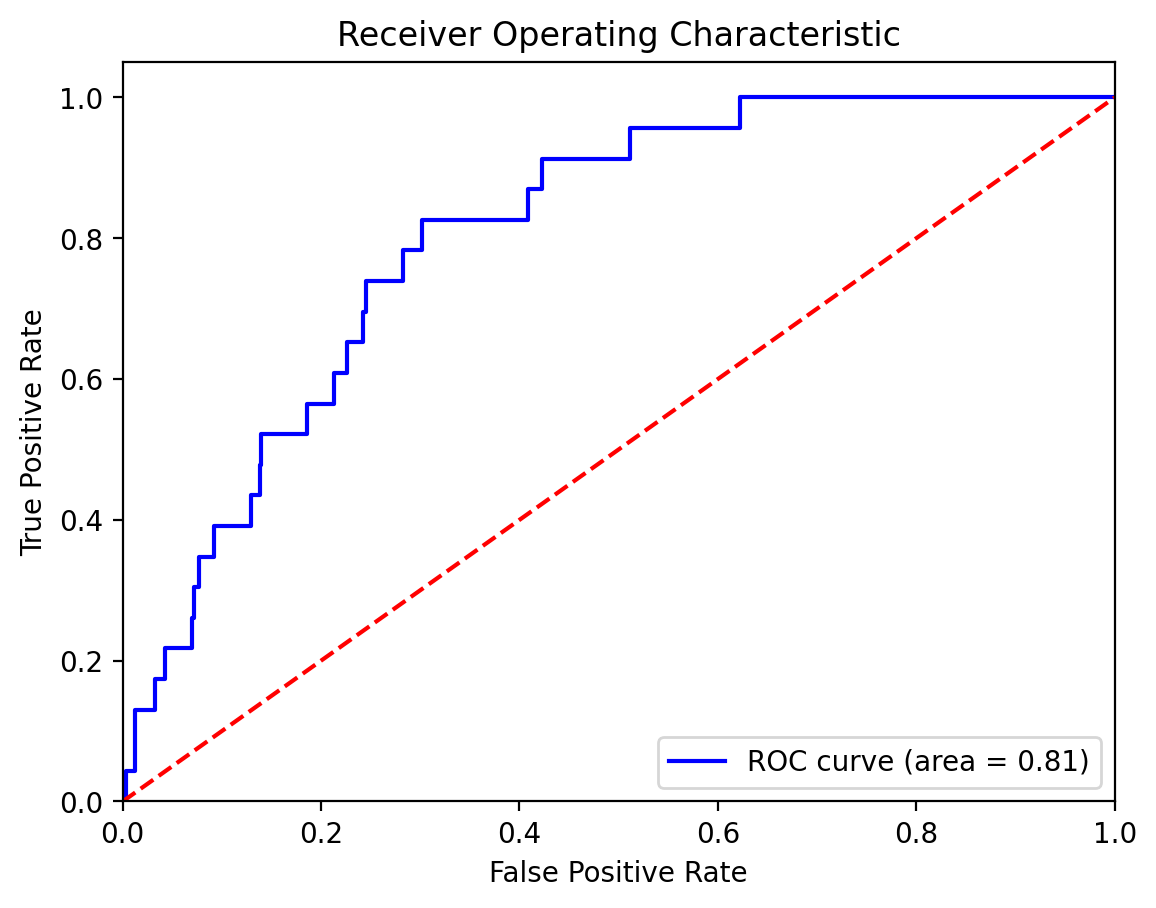

In [13]:
# ROC curve
y_pred_proba = clf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='blue', label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()


### ROC intuition: vary the alarm threshold

The **Receiver Operating Characteristic (ROC) curve** shows the trade-off between catching churners and raising false alarms as the probability threshold changes. Each point corresponds to a threshold and its resulting confusion matrix.

$$
\text{TPR}=\frac{TP}{TP+FN}=\frac{\text{churners detected}}{23},\qquad
\text{FPR}=\frac{FP}{FP+TN}=\frac{\text{non-churners incorrectly flagged}}{587}.
$$

The vertical axis is the **true positive rate (TPR)**, which is churn recall. The horizontal axis is the **false positive rate (FPR)**. FPR is calculated among actual non-churners; it is not the fraction of alarms that are wrong.

- At a sufficiently high threshold, nobody is flagged: $(FPR,TPR)=(0,0)$.
- Lowering the threshold flags more customers, potentially increasing both detections and false alarms.
- At a sufficiently low threshold, everybody is flagged: $(1,1)$.
- The ideal point is the upper-left corner $(0,1)$: detect every churner without false alarms.

For a hypothetical threshold that detects 18 churners and incorrectly flags 117 non-churners, the ROC point would be $(117/587,18/23)\approx(0.20,0.78)$. These counts illustrate the calculation; they are not a reported threshold result above.

Alternatively, sort customers from highest to lowest risk and work down the list. Passing an actual churner moves the curve upward; passing a non-churner moves it rightward. A useful ranking moves upward quickly. Tied scores are processed together. The red diagonal represents random ranking: detecting about 30% of churners would also flag about 30% of non-churners.

### Why AUC can be 0.81 when churn recall is zero

The saved plot reports **AUC = 0.81**, the area under the ROC curve. It means that a randomly selected churner receives a higher score than a randomly selected non-churner about 81% of the time, counting ties as half a success. AUC 0.5 represents random ranking; AUC 1 represents perfect separation. **AUC is not classification accuracy and does not establish probability calibration.**

At threshold 0.5, the model flags nobody. Nevertheless, its probabilities can rank churners above non-churners: hypothetical risks of 0.30, 0.12, and 0.01 all produce “no churn” at 0.5, but the first two produce “churn” at 0.10. The ROC code uses `predict_proba(X_test)[:, 1]` to evaluate thresholds based on churn scores, rather than using only the hard predictions from `predict`.

A lower threshold could detect more churners, at the cost of more false alarms. Since churn is rare, even FPR = 10% means about 59 falsely flagged non-churners, compared with only 23 actual churners. Assess precision and recall at the proposed threshold, alongside ROC AUC. Choose the threshold using validation data and the costs of missed churners versus unnecessary interventions; reserve held-out test data for final evaluation.


## Linear Discriminant Analysis

### Intuition: compare two clouds with the same shape

LDA models the distribution of predictors **within each class**, then uses Bayes' rule to infer class probabilities. Let $\pi_k=P(Y=k)$, $\mu_k$ be the class mean vector, and $\Sigma$ be a shared covariance matrix:

$$
X\mid Y=k\sim N(\mu_k,\Sigma),\qquad k\in\{0,1\}.
$$

Imagine two elliptical clouds of customers: they have different centers, but the same spread and orientation. The covariance matrix accounts for feature scales and correlations. LDA asks which cloud better explains a customer, while also accounting for how common each class is.

### Functional form

Assign each class the score

$$
\delta_k(x)=x^\top\Sigma^{-1}\mu_k
-\frac12\mu_k^\top\Sigma^{-1}\mu_k+\log\pi_k,
\qquad \widehat Y=\arg\max_{k\in\{0,1\}}\delta_k(x).
$$

The boundary $\delta_1(x)-\delta_0(x)=0$ is **linear** because the shared quadratic term cancels. The prior term matters here: churn is uncommon, so a customer needs stronger evidence to be assigned to that class.

Both LDA and logistic regression produce linear boundaries, but they learn them differently: logistic regression models $P(Y\mid X)$ directly; LDA models Gaussian distributions for $X\mid Y$ and applies Bayes' rule. The Gaussian assumptions apply to the feature distributions within classes, not to the binary outcome. They are working approximations for this dataset, which includes discrete predictors.

Reference: [scikit-learn: LDA and QDA](https://scikit-learn.org/stable/modules/lda_qda.html).


In [14]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Fit the model
clf = LinearDiscriminantAnalysis()
clf.fit(X_train, y_train)

# Make predictions with test data
y_pred = clf.predict(X_test)

# Evaluate the model with test data
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       587
           1       0.00      0.00      0.00        23

    accuracy                           0.96       610
   macro avg       0.48      0.50      0.49       610
weighted avg       0.93      0.96      0.94       610



## Quadratic Discriminant Analysis

### Intuition: each class gets its own cloud shape

QDA allows churners and non-churners to have different feature variability and correlations:

$$
X\mid Y=k\sim N(\mu_k,\Sigma_k).
$$

For example, churners might occupy a broad, tilted cloud while non-churners occupy a tighter cloud. This flexibility allows curved boundaries.

### Functional form

Ignoring constants shared by the classes, QDA uses

$$
\delta_k(x)=-\frac12\log|\Sigma_k|
-\frac12(x-\mu_k)^\top\Sigma_k^{-1}(x-\mu_k)
+\log\pi_k,
\qquad \widehat Y=\arg\max_k\delta_k(x).
$$

The determinant term accounts for the cloud's volume; the quadratic distance measures how far the customer lies from its center relative to its spread. Because the covariance matrices differ, quadratic terms generally remain when comparing scores. With two features, the boundary can be written as

$$
a+b_1x_1+b_2x_2+c_1x_1^2+c_2x_2^2+c_3x_1x_2=0.
$$

QDA can therefore capture interactions and different class shapes. If the covariance matrices are equal, it reduces to LDA. This flexibility costs parameters: each covariance matrix has $p(p+1)/2$ distinct entries. With only **19 training churners**, estimating a separate covariance for that group can be unstable. More flexibility does not guarantee better test predictions.

The code removes Patsy's constant `Intercept` column because a constant has zero variance and makes a covariance matrix singular. QDA already has class-specific constants in its scores; it does not need an intercept feature.

Reference: [scikit-learn: LDA and QDA](https://scikit-learn.org/stable/modules/lda_qda.html).


In [15]:
# Quadratic Discriminant Analysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# Drop the constant column (added by patsy): QDA needs a full-rank
# covariance matrix for each class, and a constant has zero variance
X_train_qda = X_train.drop(columns='Intercept')
X_test_qda = X_test.drop(columns='Intercept')

# Fit the model
clf = QuadraticDiscriminantAnalysis()
clf.fit(X_train_qda, y_train)

# Make predictions with test data
y_pred = clf.predict(X_test_qda)

# Evaluate the model with test data
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97       587
           1       0.11      0.04      0.06        23

    accuracy                           0.95       610
   macro avg       0.54      0.51      0.52       610
weighted avg       0.93      0.95      0.94       610



## Naive Bayes Classifier

### Intuition: combine evidence from each feature separately

Bayes' rule gives $P(Y=k\mid x)\propto\pi_k p(x\mid Y=k)$. Naive Bayes simplifies the joint feature distribution by assuming independence **conditional on the class**:

$$
p(x\mid Y=k)=\prod_{j=1}^p p(x_j\mid Y=k).
$$

Income supplies one piece of evidence about churn, transaction frequency another, and credit score another. The model combines these pieces without estimating their within-class correlations. Conditional independence does not mean that features must be independent in the pooled population.

### Functional form of `GaussianNB`

The implementation below assumes $X_j\mid Y=k\sim N(\mu_{kj},\sigma_{kj}^2)$. Its log-score, omitting constants shared by classes, is

$$
\delta_k(x)=\log\pi_k-\frac12\sum_{j=1}^p
\left[\log\sigma_{kj}^2+\frac{(x_j-\mu_{kj})^2}{\sigma_{kj}^2}\right],
\qquad \widehat Y=\arg\max_k\delta_k(x).
$$

Gaussian Naive Bayes corresponds to QDA with diagonal covariance matrices. It generally has a **quadratic boundary with squared-feature terms but no cross-feature interaction terms**. If each feature's variance is the same across classes, those squared terms cancel and the boundary becomes linear. The implementation also applies a small variance smoothing term for numerical stability.

It estimates fewer parameters than full QDA, which can help with small samples. However, correlated features can count overlapping evidence repeatedly, and Gaussian distributions are approximations for discrete predictors. “Naive” refers to the independence assumption, not to Bayes' rule itself.

Reference: [scikit-learn: relationship between QDA and Gaussian Naive Bayes](https://scikit-learn.org/stable/modules/lda_qda.html).


In [16]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB

# Fit the model
clf = GaussianNB()
clf.fit(X_train, y_train)

# Make predictions with test data
y_pred = clf.predict(X_test)

# Evaluate the model with test data
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.96      0.96       587
           1       0.14      0.17      0.15        23

    accuracy                           0.93       610
   macro avg       0.55      0.57      0.56       610
weighted avg       0.94      0.93      0.93       610



## K-Nearest Neighbors

### Intuition: similar customers vote

KNN finds the $K$ closest training customers and predicts their majority class. It does not fit a fixed global linear or quadratic equation. The first example uses $K=3$: two or three churners among the nearest neighbors produce a churn prediction.

### Functional form

For the uniform weighting used here, let $N_K(x)$ be the set of nearest neighbors. Then

$$
\widehat P(Y=1\mid x)=\frac1K\sum_{i\in N_K(x)}y_i.
$$

Predict the class with the most votes. For an even $K$, ties are possible; the implementation selects class 0 in a binary 0/1 tie. The default distance here is Euclidean:

$$
d(x,z)=\sqrt{\sum_{j=1}^p(x_j-z_j)^2}.
$$

Small $K$ gives a local, irregular boundary that can be noisy. Larger $K$ smooths the boundary, but a rare class can be overwhelmed by majority-class neighbors. Feature scaling is important: a predictor measured in thousands can dominate one measured in single digits. Any scaler should be fitted within the training folds when tuning the model.

The following grid search tries $K=1,\ldots,19$ using five-fold cross-validation. With no explicit `scoring` argument, it selects by accuracy. The saved result chooses $K=2$, but high accuracy in this imbalanced dataset does not establish useful churn detection. A churn-sensitive validation criterion may select a different model.


In [17]:
from sklearn.neighbors import KNeighborsClassifier

# Fit KNN model
clf = KNeighborsClassifier(n_neighbors=3)
clf.fit(X_train, y_train)

# Make predictions with test data
y_pred = clf.predict(X_test)

# Evaluate the model with test data
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       587
           1       0.00      0.00      0.00        23

    accuracy                           0.96       610
   macro avg       0.48      0.50      0.49       610
weighted avg       0.93      0.96      0.94       610



In [18]:
# Tuning KNN model
from sklearn.model_selection import GridSearchCV

param_grid = {'n_neighbors': np.arange(1, 20)}
knn = KNeighborsClassifier()
knn_cv = GridSearchCV(knn, param_grid, cv=5)
knn_cv.fit(X_train, y_train)

# Best parameters
print("Best parameters for KNN:", knn_cv.best_params_['n_neighbors'])
print("Best cross-validation score for KNN:", round(knn_cv.best_score_, 2))

# Make predictions with the best KNN model
y_pred = knn_cv.predict(X_test)

# Evaluate the model with test data
print(classification_report(y_test, y_pred))

Best parameters for KNN: 2
Best cross-validation score for KNN: 0.97
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       587
           1       0.00      0.00      0.00        23

    accuracy                           0.96       610
   macro avg       0.48      0.50      0.49       610
weighted avg       0.93      0.96      0.94       610



## Support Vector Machines

### Intuition: separate the classes with a wide margin

A linear SVM uses $f(x)=w^\top x+b$ and predicts according to its sign. It balances a wide separating margin against penalties for observations that lie inside the margin or on the wrong side. The training observations that determine the boundary are called **support vectors**.

With labels encoded as $\widetilde y_i\in\{-1,+1\}$, the soft-margin linear objective is

$$
\min_{w,b}\;\frac12\|w\|^2+
C\sum_{i=1}^n\max\{0,1-\widetilde y_i(w^\top x_i+b)\}.
$$

The first term favors a wide margin; the second penalizes margin violations. Larger $C$ places more weight on avoiding those violations. Unlike logistic regression, this objective does not directly fit probabilities.

### Functional form used here: RBF kernel SVM

`SVC(probability=True)` uses the default **radial basis function (RBF) kernel**, allowing a nonlinear boundary:

$$
K(x_i,x)=\exp[-\gamma\|x-x_i\|^2],
\qquad
f(x)=\sum_{i\in SV}\alpha_i\widetilde y_i K(x_i,x)+b.
$$

Here $SV$ is the set of support vectors and $\alpha_i$ are learned weights. Classify as churn when $f(x)>0$, and no churn when $f(x)<0$; the boundary is $f(x)=0$.

Each support vector exerts a positive or negative influence that fades with distance. Combining these influences bends the boundary. Larger $\gamma$ makes the influence more local and can create a more intricate boundary; smaller $\gamma$ spreads it more broadly. $C$ controls the penalty for margin violations. Scaling matters because the kernel uses distances.

`probability=True` adds probability estimation through an additional calibration procedure. The underlying SVM classification still uses its decision score; its predicted labels need not exactly match thresholding its estimated probabilities at 0.5.

References: [SVC API](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html), [SVM guide](https://scikit-learn.org/stable/modules/svm.html).


In [19]:
# Fit Support Vector Machine model
from sklearn.svm import SVC

clf = SVC(probability=True)
clf.fit(X_train, y_train)

# Make predictions with test data
y_pred = clf.predict(X_test)

# Evaluate the model with test data
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       587
           1       0.00      0.00      0.00        23

    accuracy                           0.96       610
   macro avg       0.48      0.50      0.49       610
weighted avg       0.93      0.96      0.94       610



## Comparing the classifiers in this churn example

| Method | What it learns | Typical boundary | Main trade-off |
|---|---|---|---|
| Logistic regression | Churn probability from a linear score | Linear in supplied features | Restricts the log-odds to an additive linear form |
| LDA | Gaussian class distributions with shared covariance | Linear | Uses a common class shape |
| QDA | Gaussian class distributions with separate covariances | Quadratic, including interactions | More flexibility requires more data |
| Gaussian Naive Bayes | Separate Gaussian feature distributions within each class | Quadratic without cross-feature terms | Fewer parameters, but ignores within-class dependence |
| KNN | Local class proportions among nearby training observations | Irregular and local | Sensitive to scaling, neighborhood size, and imbalance |
| RBF SVM | A margin-based boundary built from kernel similarities | Nonlinear | Sensitive to scaling and tuning of $C$ and $\gamma$ |

All methods face **590 non-churners versus 19 churners in training**. Estimated class priors favor no churn in LDA, QDA, and Naive Bayes; most available neighbors are non-churners in KNN; logistic regression and SVM also fit objectives dominated by the majority class unless adjusted.

Different models can therefore produce the same “everyone stays” labels without having identical scores or decision boundaries. Compare churn precision and recall, risk ranking through ROC AUC, and the consequences of the chosen decision threshold. Greater model flexibility alone does not solve class imbalance. Tune models and thresholds using training/validation data, then evaluate the selected procedure on held-out test data.


## Regularized logistic regression when the number of covariates grows

### Same probability model, different way of estimating coefficients

Let $n$ be the number of **training customers** and $p$ the number of covariates, excluding the intercept. Both ordinary and penalized logistic regression use

$$
\eta_i=\beta_0+x_i^\top\beta,\qquad
q_i=P(Y_i=1\mid x_i)=\frac{1}{1+e^{-\eta_i}}.
$$

Their difference is the estimation objective. Define average negative log-likelihood (log loss) as

$$
L(\beta_0,\beta)=\frac1n\sum_{i=1}^n\left[\log(1+e^{\eta_i})-y_i\eta_i\right].
$$

**Unpenalized logistic regression** minimizes $L$. **Ridge logistic regression** minimizes

$$
L(\beta_0,\beta)+\frac{\lambda}{2}\sum_{j=1}^p\beta_j^2.
$$

The intercept is not penalized. The penalty discourages large coefficients: a predictor must improve fit enough to justify the coefficient it receives. This introduces bias but can reduce variance and sensitivity to accidental patterns. The probability formula and linear boundary in the supplied features remain the same.

| Penalty | Objective added to $L$ | Intuition |
|---|---|---|
| Ridge ($L_2$), used below | $\lambda\|\beta\|_2^2/2$ | Shrinks coefficients, generally keeping every feature |
| Lasso ($L_1$) | $\lambda\|\beta\|_1$ | Can set coefficients exactly to zero, selecting features |
| Elastic net | $\lambda[\alpha\|\beta\|_1+(1-\alpha)\|\beta\|_2^2/2]$ | Combines selection and shrinkage, with $0\leq\alpha\leq1$ |

Scikit-learn uses `C` as an inverse regularization parameter: **smaller `C` means stronger shrinkage**. For the unweighted ridge objective above, $\lambda=1/(nC)$. We select `C` by cross-validation rather than choose it using test performance. Note that the earlier `LogisticRegression()` call already applies regularization by default; the comparison here explicitly removes it from the ordinary-logistic baseline.

### Why high dimensionality creates problems

As $p$ grows relative to $n$, the model gets more opportunities to fit chance correlations. Training loss may fall while test loss rises. With sufficiently many features, the training classes may become **completely separated**: a linear boundary classifies every training observation correctly. Then the unpenalized logistic likelihood can keep improving as coefficients diverge, so there is no finite maximum-likelihood estimate. An optimizer still returns a finite numerical approximation based on its tolerance and stopping rule; that is not evidence that a finite MLE exists. Separation can occur even before $p=n$, especially with rare outcomes.

Regularization limits coefficient growth and makes the problem better behaved, but it cannot create predictive information from irrelevant features. When both $n$ and $p$ grow, the number of observations relative to model complexity matters; more independent customers can help, whereas duplicating rows does not add information. For this imbalanced dataset, the number of churn events is also important.

### Experiment: hold customers fixed and add irrelevant covariates

We reuse **the same `df`, churn outcome, and original predictors (`Xbase`) from the beginning**. Because the real dataset has a fixed number of measured features, we append explicitly simulated independent standard-normal noise columns. These are illustrative irrelevant covariates, not new customer measurements or simulated outcomes.

- Hold a stratified 50/50 training/test split fixed at every dimension, with 21 churners in each split. This split is constructed for this experiment and differs from the earlier unstratified split.
- Always retain the original predictors and remove Patsy's constant `Intercept` column. Add nested sets of noise columns, moving from $p\ll n$ to $p>n$.
- Repeat with three noise seeds, keeping the same customers and split. This shows sensitivity to the added irrelevant features, **not** sampling uncertainty across new datasets.
- Standardize predictors within a `Pipeline`, so each cross-validation fold learns scaling using only its own training observations.
- Tune ridge `C` using stratified three-fold cross-validation and negative log loss on training data only. Refit the selected model on all training observations; the held-out test set is used only for the comparison plots.

We graph training log loss, test log loss, and test ROC AUC. Log loss assesses probabilities and heavily penalizes confidently wrong predictions; AUC assesses risk ranking. Accuracy would hide much of the problem because predicting no churn already gets about 97% correct. The constant-risk reference always predicts the training churn prevalence.

Reference: [scikit-learn LogisticRegression documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html).

In [20]:
# Reuse the real data/design matrix already constructed above.
import warnings
import sklearn
from packaging.version import Version
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from IPython.display import display

X_hd_base = Xbase.drop(columns='Intercept', errors='ignore').to_numpy(dtype=float)
y_hd = np.asarray(df['churn'], dtype=int)
assert len(X_hd_base) == len(y_hd)
assert np.isfinite(X_hd_base).all(), 'Resolve missing/nonfinite predictors first.'
assert set(np.unique(y_hd)) == {0, 1}

hd_train_idx, hd_test_idx = train_test_split(
    np.arange(len(y_hd)), test_size=0.5, stratify=y_hd, random_state=42
)
y_hd_train, y_hd_test = y_hd[hd_train_idx], y_hd[hd_test_idx]
n_hd_train = len(hd_train_idx)
p_hd_base = X_hd_base.shape[1]
noise_counts = np.array([0, 10, 25, 50, 100, 200, 400, 800])
noise_seeds = [524, 525, 526]
C_grid_hd = np.logspace(-4, 2, 7)
hd_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=524)

# In sklearn >=1.8, C=np.inf explicitly disables regularization.
# Older releases use penalty=None (or 'none' before version 1.2).
def make_hd_logistic(regularized):
    kwargs = dict(solver='lbfgs', max_iter=3000, tol=1e-7)
    version = Version(sklearn.__version__)
    if version >= Version('1.8'):
        kwargs.update(C=1.0 if regularized else np.inf, l1_ratio=0.0)
    else:
        kwargs['penalty'] = 'l2' if regularized else (None if version >= Version('1.2') else 'none')
        kwargs['C'] = 1.0
    return Pipeline([
        ('scale', StandardScaler()),
        ('logit', LogisticRegression(**kwargs))
    ])

# Compute log loss from logits, avoiding probability clipping when ordinary
# logistic regression makes extremely confident predictions after separation.
def hd_log_loss_from_scores(y_true, scores):
    return float(np.mean(np.logaddexp(0.0, (1 - 2 * y_true) * scores)))

hd_prevalence = y_hd_train.mean()
hd_null_score = np.log(hd_prevalence / (1 - hd_prevalence))
hd_null_train_loss = hd_log_loss_from_scores(y_hd_train, hd_null_score)
hd_null_test_loss = hd_log_loss_from_scores(y_hd_test, hd_null_score)
print(f'scikit-learn {sklearn.__version__}')
print(f'Training: n={n_hd_train}, churners={y_hd_train.sum()}; '
      f'test: n={len(hd_test_idx)}, churners={y_hd_test.sum()}')
print(f'Original p={p_hd_base}; total p values={list(p_hd_base + noise_counts)}')
print('Same rows at every p; intercept excluded from p; no class weighting.')

scikit-learn 1.9.0
Training: n=609, churners=21; test: n=610, churners=21
Original p=9; total p values=[np.int64(9), np.int64(19), np.int64(34), np.int64(59), np.int64(109), np.int64(209), np.int64(409), np.int64(809)]
Same rows at every p; intercept excluded from p; no class weighting.


In [21]:
hd_rows = []
hd_fit_diagnostics = []
for seed in noise_seeds:
    # Prefixes of one noise matrix give nested models within each repeat.
    rng_hd = np.random.default_rng(seed)
    hd_noise = rng_hd.standard_normal((len(y_hd), int(noise_counts.max())))
    for q in noise_counts:
        X_hd = np.column_stack([X_hd_base, hd_noise[:, :q]])
        X_hd_train, X_hd_test = X_hd[hd_train_idx], X_hd[hd_test_idx]
        p_hd = X_hd.shape[1]

        ordinary_hd = make_hd_logistic(regularized=False)
        ridge_search_hd = GridSearchCV(
            make_hd_logistic(regularized=True),
            {'logit__C': C_grid_hd},
            scoring='neg_log_loss', cv=hd_cv, refit=True,
            n_jobs=1, error_score='raise'
        )
        # Earlier cells suppress warnings globally. Capture convergence warnings
        # explicitly here and report them instead of silently discarding them.
        with warnings.catch_warnings(record=True) as fit_warnings:
            warnings.simplefilter('always', ConvergenceWarning)
            ordinary_hd.fit(X_hd_train, y_hd_train)
            ridge_search_hd.fit(X_hd_train, y_hd_train)
        convergence_messages = [str(w.message) for w in fit_warnings
                                if issubclass(w.category, ConvergenceWarning)]
        hd_fit_diagnostics.append({
            'seed': seed, 'p': p_hd,
            'convergence_warnings': len(convergence_messages)
        })

        for name, estimator in [
            ('Unpenalized', ordinary_hd),
            ('Ridge (CV)', ridge_search_hd.best_estimator_)
        ]:
            train_scores = estimator.decision_function(X_hd_train)
            test_scores = estimator.decision_function(X_hd_test)
            hd_rows.append({
                'seed': seed, 'p': p_hd, 'p_over_n': p_hd / n_hd_train,
                'model': name,
                'train_log_loss': hd_log_loss_from_scores(y_hd_train, train_scores),
                'test_log_loss': hd_log_loss_from_scores(y_hd_test, test_scores),
                'test_auc': roc_auc_score(y_hd_test, test_scores),
                'coefficient_norm': np.linalg.norm(estimator.named_steps['logit'].coef_),
                'separates_training': bool(np.all((2 * y_hd_train - 1) * train_scores > 0)),
                'best_C': ridge_search_hd.best_params_['logit__C'] if name == 'Ridge (CV)' else np.nan
            })
    print(f'Completed noise seed {seed}.')

hd_results = pd.DataFrame(hd_rows)
hd_diagnostics = pd.DataFrame(hd_fit_diagnostics)
assert len(hd_results) == len(noise_seeds) * len(noise_counts) * 2
assert np.isfinite(hd_results[['train_log_loss', 'test_log_loss', 'test_auc']]).all().all()
assert hd_results['test_auc'].between(0, 1).all()
print('Captured convergence warnings:', hd_diagnostics['convergence_warnings'].sum())
print('A zero warning count does not rule out complete separation.')
hd_summary = hd_results.groupby(['p', 'model']).agg(
    train_log_loss=('train_log_loss', 'mean'),
    test_log_loss=('test_log_loss', 'mean'),
    test_auc=('test_auc', 'mean'),
    coefficient_norm=('coefficient_norm', 'mean'),
    separated_runs=('separates_training', 'sum')
).round(4)
display(hd_summary)
print('Ridge C selected for each p and noise seed:')
display(hd_results.query("model == 'Ridge (CV)'").pivot(index='p', columns='seed', values='best_C'))

Completed noise seed 524.
Completed noise seed 525.
Completed noise seed 526.
Captured convergence warnings: 0
A zero warning count does not rule out complete separation.


train_log_loss  test_log_loss  test_auc  coefficient_norm  \
p   model                                                                    
9   Ridge (CV)           0.1123         0.1324    0.7793            1.8047   
    Unpenalized          0.1115         0.1337    0.7882            2.3775   
19  Ridge (CV)           0.1010         0.1506    0.7210            1.9511   
    Unpenalized          0.0967         0.1649    0.7407            3.1129   
34  Ridge (CV)           0.0990         0.1492    0.6641            1.2312   
    Unpenalized          0.0820         0.2134    0.6938            4.0790   
59  Ridge (CV)           0.0977         0.1525    0.6551            1.0722   
    Unpenalized          0.0545         0.7811    0.6373           12.5155   
109 Ridge (CV)           0.0973         0.1552    0.6407            0.8364   
    Unpenalized          0.0000         3.2235    0.5765           45.0150   
209 Ridge (CV)           0.0979         0.1480    0.5999            0.5159   
    Unpenalized          0.0000         1.3638    0.5310           17.7404   
409 Ridge (CV)           0.0693         0.1458    0.6436            0.6131   
    Unpenalized          0.0000         0.7008    0.6005           10.7520   
809 Ridge (CV)           0.0975         0.1499    0.6041            0.2930   
    Unpenalized          0.0000         0.5386    0.5832            7.6210   

                 separated_runs  
p   model                        
9   Ridge (CV)                0  
    Unpenalized               0  
19  Ridge (CV)                0  
    Unpenalized               0  
34  Ridge (CV)                0  
    Unpenalized               0  
59  Ridge (CV)                0  
    Unpenalized               0  
109 Ridge (CV)                0  
    Unpenalized               3  
209 Ridge (CV)                0  
    Unpenalized               3  
409 Ridge (CV)                0  
    Unpenalized               3  
809 Ridge (CV)                0  
    Unpenalized               3

Ridge C selected for each p and noise seed:


seed,524,525,526
p,,,
9,1.000,1.000,1.00
19,1.000,1.000,0.10
34,0.100,0.100,0.10
59,0.010,0.100,0.10
109,0.010,0.010,0.10
209,0.010,0.010,0.01
409,0.010,0.010,0.01
809,0.001,0.001,0.01


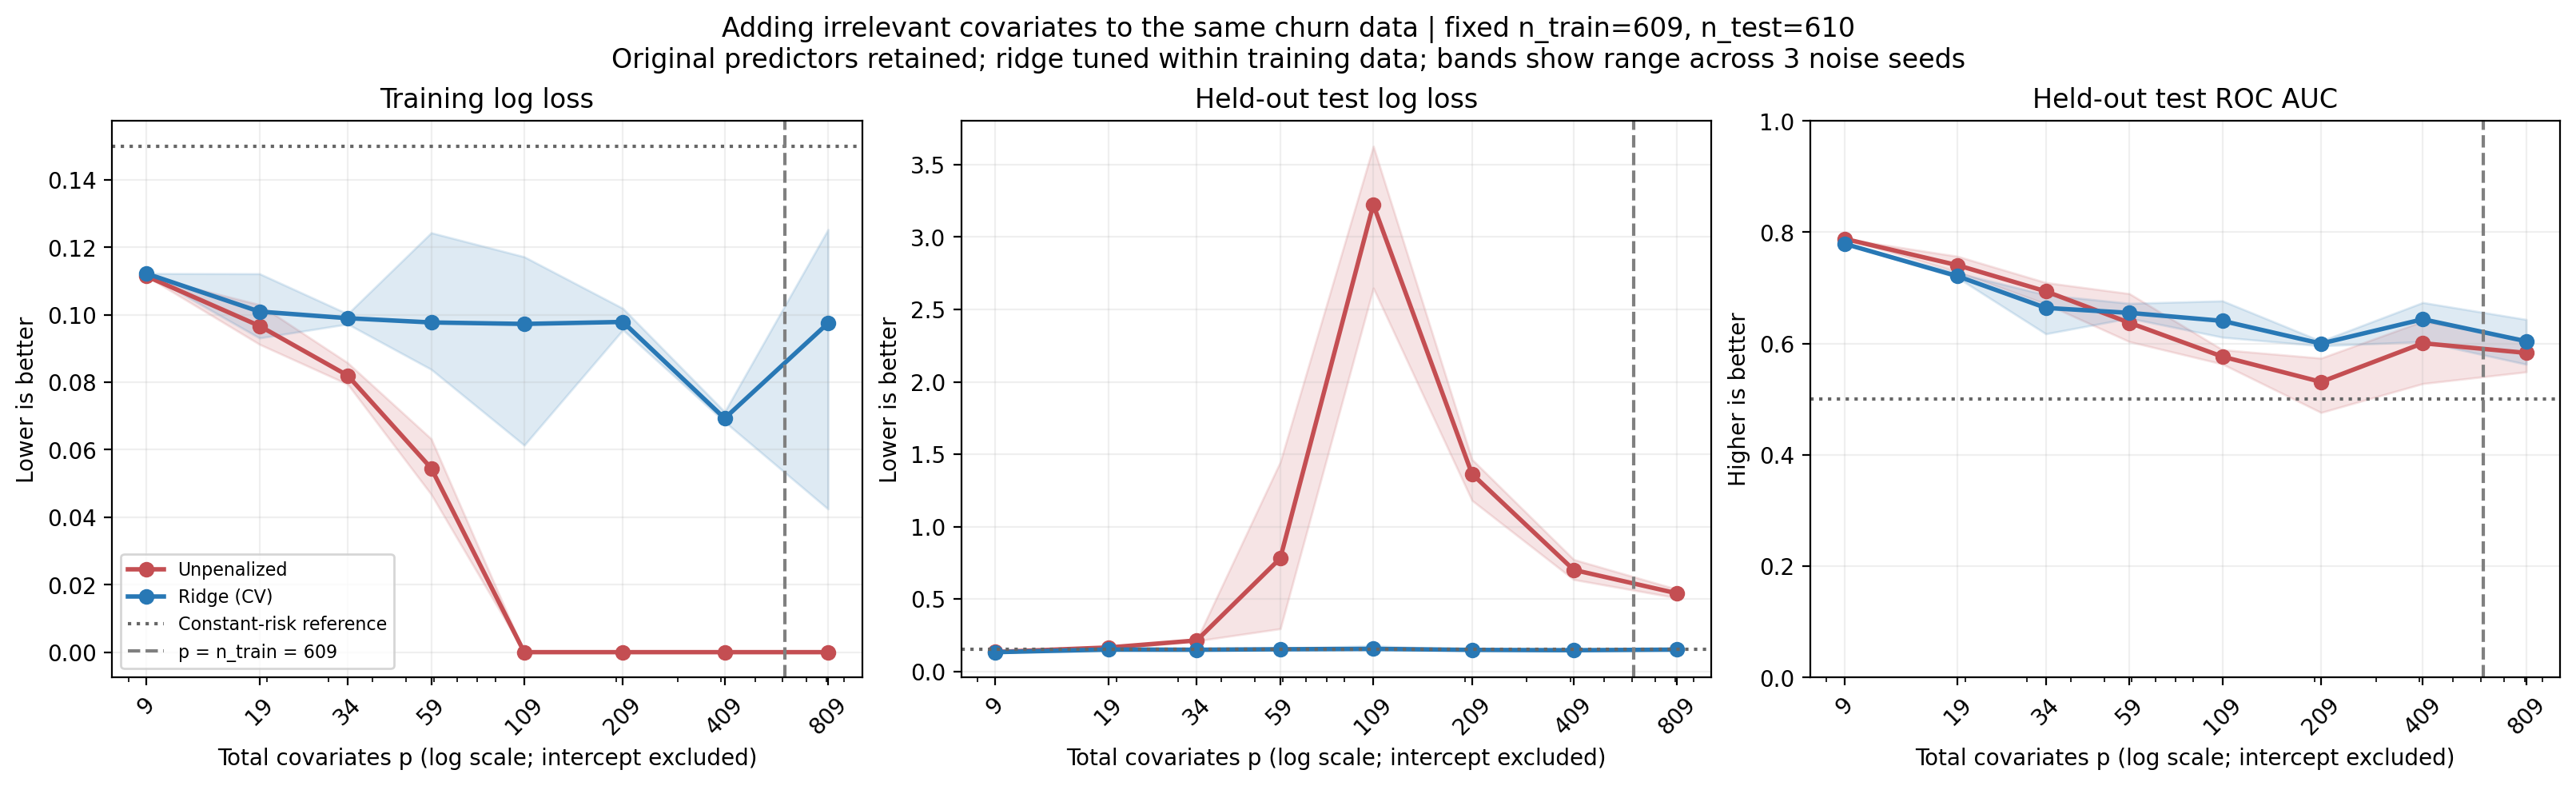

In [22]:
# Solid lines: mean over noise seeds. Shaded bands: min-to-max over those seeds.
# They are descriptive variability bands, not confidence intervals.
fig_hd, axes_hd = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
colors_hd = {'Unpenalized': '#c44e52', 'Ridge (CV)': '#2878b5'}
panels_hd = [
    ('train_log_loss', 'Training log loss', 'Lower is better'),
    ('test_log_loss', 'Held-out test log loss', 'Lower is better'),
    ('test_auc', 'Held-out test ROC AUC', 'Higher is better')
]
for ax, (metric, title, direction) in zip(axes_hd, panels_hd):
    for name, color in colors_hd.items():
        grouped = hd_results.loc[hd_results['model'] == name].groupby('p')[metric]
        means, lower, upper = grouped.mean(), grouped.min(), grouped.max()
        ax.plot(means.index, means.values, 'o-', color=color, label=name, linewidth=2)
        ax.fill_between(means.index, lower.values, upper.values, color=color, alpha=0.15)
    reference = (0.5 if metric == 'test_auc' else
                 hd_null_train_loss if metric == 'train_log_loss' else hd_null_test_loss)
    ax.axhline(reference, color='0.4', linestyle=':', label='Constant-risk reference')
    ax.axvline(n_hd_train, color='0.5', linestyle='--', label=f'p = n_train = {n_hd_train}')
    ax.set_xscale('log')
    ax.set_xticks(p_hd_base + noise_counts)
    ax.set_xticklabels(p_hd_base + noise_counts, rotation=45)
    ax.set_xlabel('Total covariates p (log scale; intercept excluded)')
    ax.set_title(title)
    ax.set_ylabel(direction)
    ax.grid(alpha=0.2)
axes_hd[2].set_ylim(0, 1)
axes_hd[0].legend(fontsize=8, loc='best')
fig_hd.suptitle(
    f'Adding irrelevant covariates to the same churn data | '
    f'fixed n_train={n_hd_train}, n_test={len(hd_test_idx)}\n'
    'Original predictors retained; ridge tuned within training data; bands show range across 3 noise seeds',
    fontsize=12
)
plt.show()

### How to read the experiment

1. **Training loss:** Additional covariates give the unpenalized model more ways to fit the training labels. Nearly zero training loss can reflect memorization and separation, rather than genuine predictive information. Ridge deliberately accepts a worse training fit to control coefficient size.
2. **Test loss:** A widening train/test gap for the unpenalized model indicates overfitting. Confidently wrong predictions are expensive under log loss. Compare ridge with both ordinary logistic regression and the constant-risk reference: beating an unstable unpenalized fit is not the same as preserving useful signal.
3. **Test AUC:** A model can retain some risk-ranking ability while assigning poorly calibrated, excessively extreme probabilities. Thus AUC and log loss can tell different stories. Ridge can also lose ranking quality as noise accumulates; regularization is not immunity to irrelevant features.
4. **The dashed $p=n_{\rm train}$ line:** This is a dimensionality reference, not an exact threshold at which problems begin. Complete separation may occur well to its left. The summary table reports how many of the three numerical fits separate the training observations and the norm of the standardized coefficients.

The noise-free point is repeated identically across seeds; only the added noise changes. The shaded range is not a confidence interval, and the curves need not be monotone. This is one controlled illustration on a small, imbalanced dataset, not a guarantee that ridge wins at every dimension or on every dataset. If selected `C` values lie at a grid edge, a subsequent training-only analysis could expand that grid; do not choose a grid or model by chasing these test curves.

To study growing $n$ as well, one could use nested subsets of the training pool at several sample sizes while keeping a separate test set fixed. Here $n$ is deliberately held fixed so the graph isolates increasing $p$ without changing which customers supply information.

### What the saved run shows

With the original $p=9$ features, the models perform similarly: test log loss is about **0.134 unpenalized versus 0.132 ridge**. At $p=109$, ordinary logistic regression separates all training observations in all three noise repetitions, while its mean test log loss rises to about **3.22**, compared with **0.155 for ridge**. This is a concrete example of excellent training fit failing to generalize, well before $p=n_{\rm train}=609$.

At $p=809$, mean test AUC is about **0.58 unpenalized versus 0.60 ridge**, down from approximately 0.79 and 0.78 at $p=9$. Ridge controls the extreme probability errors much better, but it does not preserve all of the original ranking signal. Its test loss at high dimensions is close to the constant-risk reference.

The unpenalized test-loss curve peaks and then falls in this numerical experiment; it does not increase monotonically with $p$. After separation, there is no finite unpenalized MLE, so the returned coefficients and losses depend on the optimizer's stopping rule. This curve should not be interpreted as a universal high-dimensional risk law or proof that adding enough irrelevant covariates cures overfitting. The numerical summaries above describe the saved run and may vary slightly across solver versions.


## Interactive classroom game: you control the churn alarm

You run the customer-retention desk. Move the **probability threshold** to decide who gets flagged for a “please stay!” offer. Watch the customer colors, confusion matrix, precision, recall, and ROC point change together.

**Challenge:** catch at least 80% of the churners while flagging as few customers as possible. Start at 50%, then try 10% and 3%. The probabilities and ROC AUC stay fixed; only the classification rule changes.

Run the two cells below after loading `df` and constructing `Xbase`. The demo uses the same churn data, a fixed stratified split, and logistic regression with standardized original predictors (no simulated noise). This is a separate fit, so its results can differ from the earlier unscaled example. If your notebook viewer blocks interactive HTML, open the generated **churn_threshold_playground.html** in a browser; it works offline without Python or widget extensions.

In [23]:
# Fit once; the slider will only change the probability cutoff.
import json
import html
from pathlib import Path
from IPython.display import HTML, display, FileLink
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score

alarm_X = Xbase.drop(columns='Intercept', errors='ignore')
alarm_y = df['churn'].to_numpy(dtype=int)
alarm_train_X, alarm_test_X, alarm_train_y, alarm_test_y = train_test_split(
    alarm_X, alarm_y, test_size=0.5, stratify=alarm_y, random_state=42
)
# Scaling is learned on training data only; C=1 retains the default L2 penalty.
alarm_model = make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=3000))
alarm_model.fit(alarm_train_X, alarm_train_y)
alarm_scores = alarm_model.predict_proba(alarm_test_X)[:, 1]
alarm_fpr, alarm_tpr, _ = roc_curve(alarm_test_y, alarm_scores, drop_intermediate=False)
alarm_data = {
    'training_n': len(alarm_train_y),
    'customers': [{'probability': float(p), 'actual': int(y)}
                  for p, y in zip(alarm_scores, alarm_test_y)],
    'roc': np.column_stack([alarm_fpr, alarm_tpr]).tolist(),
    'auc': float(roc_auc_score(alarm_test_y, alarm_scores)),
}


In [24]:
# Self-contained HTML/SVG: slider updates run in the browser, without refitting.
# The long template below handles the visual layout and JavaScript callbacks.
alarm_template = r'''
<!doctype html>
<html lang="en">
<head><meta charset="utf-8"><meta name="viewport" content="width=device-width,initial-scale=1">
<title>The churn alarm: threshold playground</title>
<style>
*{box-sizing:border-box}body{margin:0;background:#f3f6fa;color:#183047;font:15px system-ui,-apple-system,sans-serif}.app{max-width:1180px;margin:auto;padding:24px}h1{font-size:27px;margin:4px 0 8px}h2{font-size:16px;margin:0 0 10px}p{line-height:1.5;margin:8px 0}.eyebrow{font-size:12px;letter-spacing:1.5px;color:#40647f;font-weight:700}.muted{color:#54697b;font-size:13px}.controls,.panel,.metric{background:white;border:1px solid #dbe4ee;border-radius:12px;padding:16px}.controls{margin:18px 0}.slider-row{display:flex;align-items:center;gap:16px;flex-wrap:wrap}input[type=range]{flex:1;min-width:210px;accent-color:#375ac5}output{font-size:26px;font-weight:750;min-width:95px}button{background:#f1f5ff;border:1px solid #b9c8e7;border-radius:7px;padding:7px 12px;margin:5px 6px 0 0;color:#263f70;cursor:pointer}button:hover{background:#e1eaff}button:focus-visible,input:focus-visible{outline:3px solid #f0aa29;outline-offset:3px}.metrics{display:grid;grid-template-columns:repeat(4,1fr);gap:12px}.metric strong{display:block;font-size:25px;margin:5px 0}.plots{display:grid;grid-template-columns:2.3fr 1fr;gap:14px;margin:14px 0}.bottom{display:grid;grid-template-columns:1.2fr 1fr;gap:14px}svg{width:100%;height:auto;display:block}svg text{font-family:system-ui,sans-serif;fill:#465d70;font-size:12px}.legend{display:flex;gap:12px;flex-wrap:wrap;font-size:12px}.swatch{display:inline-block;width:10px;height:10px;margin-right:4px;border-radius:50%}.tn{background:#dcecfb}.fp{background:#fff0cc}.fn{background:#fce1eb}.tp{background:#d5f1e9}table{border-collapse:separate;border-spacing:4px;width:100%;font-size:13px;text-align:center}th{font-weight:600;padding:6px}td{padding:9px;border-radius:7px}td strong{display:block;font-size:23px}.mission{border-left:4px solid #375ac5;padding-left:12px}#story{min-height:46px}@media(max-width:700px){.plots,.bottom{grid-template-columns:1fr}.metrics{grid-template-columns:repeat(2,1fr)}.app{padding:12px}}
</style></head>
<body><main class="app">
<div class="eyebrow">ECON 524 · CLASSIFICATION LAB</div>
<h1>You control the churn alarm</h1>
<p>You run the retention desk. Who gets a “please stay!” offer? Flag a customer when their predicted churn probability is <b>at least the threshold</b>.</p>
<p class="muted" id="dataset"></p>
<section class="controls" aria-label="Threshold controls">
<div class="slider-row"><label for="threshold"><b>Probability threshold</b></label><input id="threshold" type="range" min="0" max="100" step="0.1" value="50"><output id="threshold-label" for="threshold">50.0%</output></div>
<div><button type="button" data-threshold="50">50%: default</button><button type="button" data-threshold="10">10%: more alerts</button><button type="button" data-threshold="3">3%: cast a wider net</button><button type="button" data-threshold="0">Flag everyone</button><button type="button" data-threshold="100">Flag nobody*</button></div>
<p class="muted">Use the slider or arrow keys. The model and its probabilities stay fixed. *At 100%, nobody is flagged in this dataset.</p>
</section>
<section class="metrics" aria-label="Live performance">
<div class="metric"><span>Customers to contact</span><strong id="flagged"></strong><span class="muted" id="flagged-note"></span></div>
<div class="metric"><span>Precision</span><strong id="precision"></strong><span class="muted">Of those flagged, who churned?</span></div>
<div class="metric"><span>Recall / TPR</span><strong id="recall"></strong><span class="muted">Of all churners, who was caught?</span></div>
<div class="metric"><span>Accuracy</span><strong id="accuracy"></strong><span class="muted">Watch the majority-class trap.</span></div>
</section>
<section class="plots">
<div class="panel"><h2>Each dot is one held-out customer</h2><svg id="customers" viewBox="0 0 720 280" role="img" aria-label="Customer probabilities and moving classification threshold"></svg>
<div class="legend"><span><i class="swatch" style="background:#2878b5"></i>TN: correctly left alone</span><span><i class="swatch" style="background:#b97d00"></i>FP: false alarm</span><span><i class="swatch" style="background:#be3f72"></i>FN: missed churner</span><span><i class="swatch" style="background:#14836c"></i>TP: caught churner</span></div>
<p class="muted">Rows show actual outcomes. Dots to the right of the line are flagged. Vertical jitter separates overlapping dots; it has no statistical meaning. Hover for a customer's score.</p></div>
<div class="panel"><h2>Your position on the ROC curve</h2><svg id="roc" viewBox="0 0 300 280" role="img" aria-label="ROC curve with selected threshold marked"></svg><p class="muted" id="roc-caption"></p></div>
</section>
<section class="bottom">
<div class="panel"><h2>Live confusion matrix</h2><table><thead><tr><th>Actual ↓ / Predicted →</th><th>No churn</th><th>Churn</th></tr></thead><tbody><tr><th>No churn</th><td class="tn">True negatives<strong id="tn"></strong></td><td class="fp">False positives<strong id="fp"></strong></td></tr><tr><th>Churn</th><td class="fn">False negatives<strong id="fn"></strong></td><td class="tp">True positives<strong id="tp"></strong></td></tr></tbody></table></div>
<div class="panel"><h2>Classroom challenge</h2><p class="mission"><b>Catch at least 80% of churners.</b> Among thresholds that achieve this, try to flag as few customers as possible. How many offers go to customers who stayed?</p><p id="story" aria-live="polite"></p><p class="muted">This is a retrospective teaching game: flags are predictions, not evidence that an offer would prevent churn. In practice, choose a threshold using validation data and business costs, then assess it on a separate test set.</p></div>
</section>
</main>
<script>
const DATA = __CHURN_DATA__;
const slider = document.getElementById('threshold');
const el = id => document.getElementById(id);
const colors = {tn:'#2878b5',fp:'#b97d00',fn:'#be3f72',tp:'#14836c'};
const totalPositive = DATA.customers.filter(d => d.actual === 1).length;
const totalNegative = DATA.customers.length - totalPositive;
const percent = x => (100*x).toFixed(1)+'%';
// A fixed, slightly zoomed axis uses the observed score range, not the threshold.
const scoreMax = Math.min(1, Math.max(0.1, Math.ceil(Math.max(...DATA.customers.map(d=>d.probability))*10)/10));
const cx = p => 128 + 570*p/scoreMax;
function countsAt(t) {
  const c = {tn:0,fp:0,fn:0,tp:0};
  DATA.customers.forEach(d => {
    const predicted = d.probability >= t;
    c[d.actual === 1 ? (predicted ? 'tp':'fn') : (predicted ? 'fp':'tn')]++;
  });
  return c;
}
function render() {
  const threshold = Number(slider.value)/100;
  const c = countsAt(threshold), flagged = c.tp+c.fp;
  const recall = c.tp/totalPositive, fpr = c.fp/totalNegative;
  el('threshold-label').textContent = percent(threshold);
  el('flagged').textContent = flagged+' / '+DATA.customers.length;
  el('flagged-note').textContent = c.tp+' caught churners + '+c.fp+' false alarms';
  el('precision').textContent = flagged ? percent(c.tp/flagged) : 'N/A';
  el('recall').textContent = percent(recall);
  el('accuracy').textContent = percent((c.tp+c.tn)/DATA.customers.length);
  ['tn','fp','fn','tp'].forEach(k => el(k).textContent = c[k]);

  // Recolor fixed customer locations; no model refitting occurs on slider input.
  let scatter = '<rect x="128" y="28" width="570" height="186" fill="#f5f9fd"/>';
  if(threshold <= scoreMax) scatter += `<rect x="${cx(threshold)}" y="28" width="${cx(scoreMax)-cx(threshold)}" height="186" fill="#e9eefa"/>`;
  for(let i=0;i<=5;i++) {
    const x=cx(scoreMax*i/5);
    scatter += `<line x1="${x}" x2="${x}" y1="28" y2="214" stroke="#dfe7ef"/><text x="${x}" y="234" text-anchor="middle">${percent(scoreMax*i/5)}</text>`;
  }
  scatter += '<text x="116" y="82" text-anchor="end">Actually stayed</text><text x="116" y="179" text-anchor="end">Actually churned</text><text x="413" y="264" text-anchor="middle">Predicted probability of churn</text>';
  DATA.customers.forEach((d,i) => {
    const predicted=d.probability>=threshold;
    const type=d.actual===1?(predicted?'tp':'fn'):(predicted?'fp':'tn');
    const y=(d.actual?176:80)+(((i*37)%101)/100-0.5)*55;
    scatter += `<circle cx="${cx(d.probability)}" cy="${y}" r="${d.actual?4.5:3}" fill="${colors[type]}" fill-opacity="0.75" stroke="white" stroke-width="0.4"><title>Customer ${i+1}: risk ${percent(d.probability)}; actual ${d.actual?'churn':'no churn'}; predicted ${predicted?'churn':'no churn'}</title></circle>`;
  });
  if(threshold<=scoreMax) {
    const x=cx(threshold), anchor=threshold>scoreMax*0.8?'end':'start';
    scatter += `<line x1="${x}" x2="${x}" y1="25" y2="215" stroke="#273c86" stroke-width="2" stroke-dasharray="5 3"/><text x="${x}" y="18" text-anchor="${anchor}">Threshold: ${percent(threshold)}</text>`;
  } else scatter += `<text x="695" y="18" text-anchor="end">Threshold ${percent(threshold)} is beyond the plotted scores →</text>`;
  el('customers').innerHTML=scatter;

  const rx=x=>45+225*x, ry=y=>228-195*y;
  let roc='<rect x="45" y="33" width="225" height="195" fill="#f5f9fd"/>';
  for(const v of [0,0.5,1]) roc+=`<line x1="${rx(v)}" x2="${rx(v)}" y1="33" y2="228" stroke="#dfe7ef"/><line x1="45" x2="270" y1="${ry(v)}" y2="${ry(v)}" stroke="#dfe7ef"/><text x="${rx(v)}" y="246" text-anchor="middle">${v}</text><text x="37" y="${ry(v)+4}" text-anchor="end">${v}</text>`;
  roc+='<line x1="45" y1="228" x2="270" y2="33" stroke="#8997a5" stroke-dasharray="4 4"/>';
  roc+=`<polyline points="${DATA.roc.map(d=>rx(d[0])+','+ry(d[1])).join(' ')}" fill="none" stroke="#2878b5" stroke-width="2"/><circle cx="${rx(fpr)}" cy="${ry(recall)}" r="6" fill="#be3f72" stroke="white" stroke-width="2"/><text x="157" y="271" text-anchor="middle">False positive rate</text><text x="13" y="132" transform="rotate(-90 13 132)" text-anchor="middle">True positive rate</text>`;
  el('roc').innerHTML=roc;
  el('roc-caption').textContent=`FPR: ${percent(fpr)} · TPR: ${percent(recall)} · AUC: ${DATA.auc.toFixed(3)} (unchanged)`;
  el('story').textContent=(recall>=0.8?'Target reached! ':'Keep exploring: ')+`You catch ${c.tp} of ${totalPositive} churners, miss ${c.fn}, and flag ${c.fp} customers who stayed.`+(flagged?'':' Precision is undefined because nobody is flagged.');
}
el('dataset').textContent=`Logistic regression · ${DATA.training_n} training customers · ${DATA.customers.length} held-out customers (${totalPositive} churners) · original churn predictors, no added noise.`;
slider.addEventListener('input',render);
document.querySelectorAll('[data-threshold]').forEach(button=>button.addEventListener('click',()=>{slider.value=button.dataset.threshold;render();}));
render();
</script></body></html>
'''
alarm_page = alarm_template.replace('__CHURN_DATA__', json.dumps(alarm_data, allow_nan=False))
# Export the same interactive view for teaching outside Jupyter.
alarm_file = Path('churn_threshold_playground.html')
alarm_file.write_text(alarm_page, encoding='utf-8')
display(FileLink(str(alarm_file), result_html_prefix='Open the standalone browser version: '))
# An isolated frame keeps styles and element IDs separate from the notebook.
display(HTML(
    '<iframe title="Interactive churn threshold playground" '
    'style="width:100%;height:1080px;border:0" '
    'sandbox="allow-scripts" srcdoc="' + html.escape(alarm_page, quote=True) + '"></iframe>'
))


/Users/joelreyes/Documents/GitHub/ECON-524-Big-Data-Econometrics/lab/churn_threshold_playground.html